# 3. Exploratory Data Analysis

This notebook explores the distribution of 30-day readmission, patient characteristics, healthcare utilization, and encounter-level factors to identify patterns relevant to readmission risk and post-discharge resource prioritization.

## 3.1 Analysis Setup

The processed dataset is loaded for exploratory analysis. A binary target variable is created to distinguish encounters followed by readmission within 30 days from all other encounters.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load processed data
df = pd.read_csv("../data/processed/diabetic_data_mapped.csv")

# Create binary 30-day readmission target
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

# Viridis visual theme
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.15, 0.85, 5))

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11
})

df.shape

(101763, 50)

## 3.2 Target Variable Analysis

The distribution of 30-day readmission is examined to establish the baseline outcome prevalence and assess class imbalance.

In [9]:
target_summary = (
    df["readmitted_30d"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not Readmitted", 1: "Readmitted <30 Days"})
    .to_frame("Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] / len(df) * 100
).round(2)

target_summary

,Count,Percentage
readmitted_30d,,
Not Readmitted,90406,88.84
Readmitted <30 Days,11357,11.16


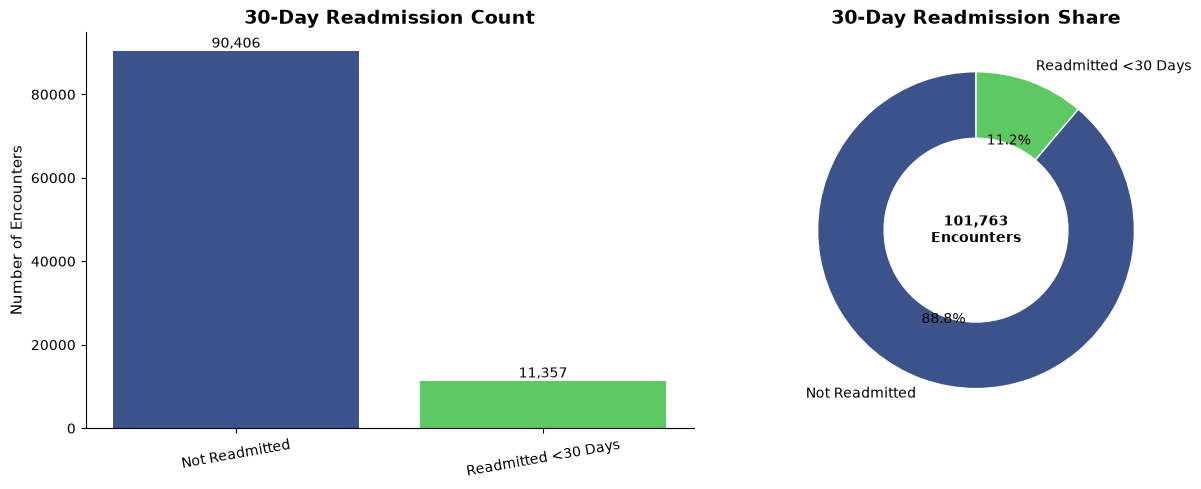

In [10]:
# Target distribution
target_counts = df["readmitted_30d"].value_counts().sort_index()
labels = ["Not Readmitted", "Readmitted <30 Days"]
plot_colors = [cmap(0.25), cmap(0.75)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — counts
bars = axes[0].bar(
    labels,
    target_counts.values,
    color=plot_colors
)

axes[0].set_title("30-Day Readmission Count")
axes[0].set_ylabel("Number of Encounters")
axes[0].tick_params(axis="x", rotation=10)

# Add count labels
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

# Donut chart — percentages
axes[1].pie(
    target_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=plot_colors,
    wedgeprops={"width": 0.42, "edgecolor": "white"}
)

axes[1].text(
    0, 0,
    f"{len(df):,}\nEncounters",
    ha="center",
    va="center",
    fontweight="bold"
)

axes[1].set_title("30-Day Readmission Share")

plt.tight_layout()
plt.show()

Of the 101,763 hospital encounters, 11,357 (11.2%) resulted in readmission within 30 days, while 90,406 (88.8%) did not.

The target variable is therefore imbalanced, with 30-day readmissions representing approximately one in nine encounters. This imbalance should be considered during predictive modeling and model evaluation.

## 3.3 Univariate Analysis

The distributions of selected patient, healthcare utilization, clinical, and encounter characteristics are examined to understand the population represented in the dataset.

### 3.3.1 Patient Characteristics

Age, gender, and race distributions are examined to understand the demographic composition of hospital encounters.

Age distribution

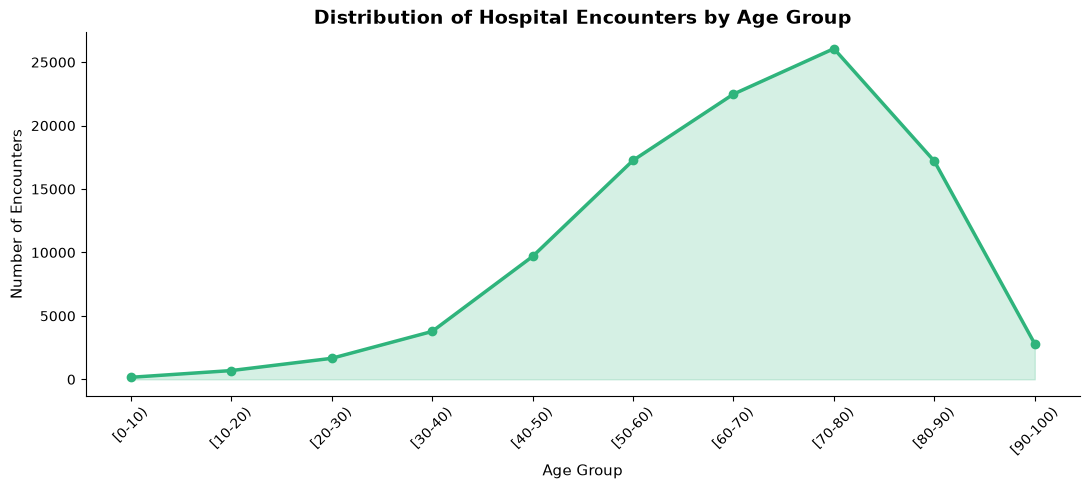

In [11]:
# Define age order
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_counts = (
    df["age"]
    .value_counts()
    .reindex(age_order)
)

# Plot age distribution
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    age_order,
    age_counts.values,
    marker="o",
    linewidth=2.5,
    color=cmap(0.65)
)

ax.fill_between(
    age_order,
    age_counts.values,
    alpha=0.20,
    color=cmap(0.65)
)

ax.set_title("Distribution of Hospital Encounters by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Encounters")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Hospital encounters increase progressively with age and peak among patients aged 70–80 years. Most encounters are concentrated among patients aged 50–90 years, while younger age groups account for relatively few encounters.

Gender and Race Distribution 

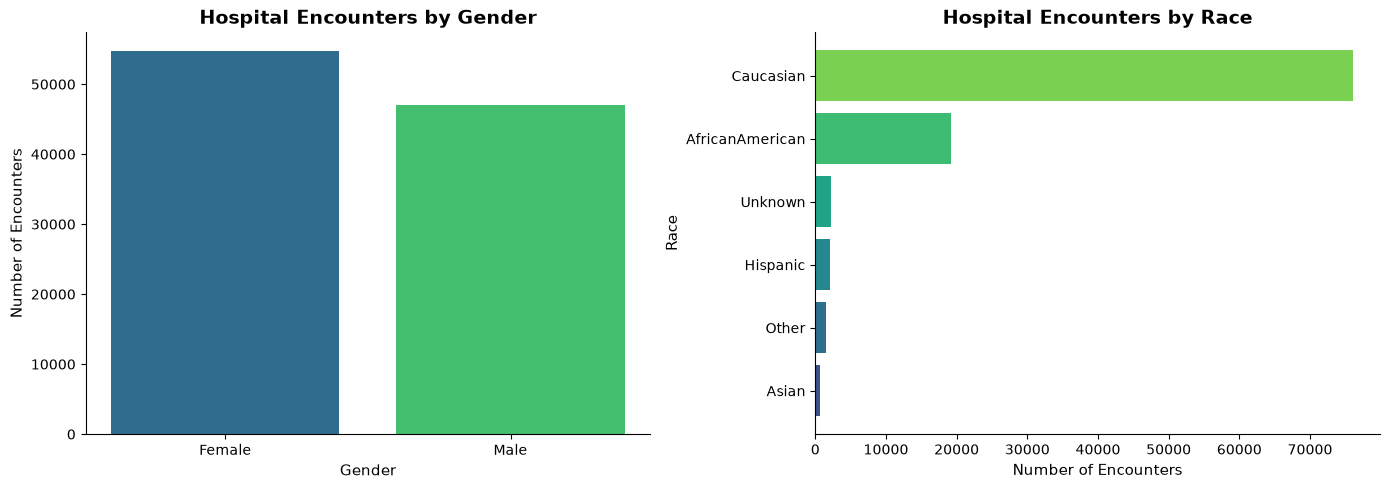

In [12]:
# Prepare distributions
gender_counts = df["gender"].value_counts()
race_counts = df["race"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender — vertical bars
axes[0].bar(
    gender_counts.index,
    gender_counts.values,
    color=[cmap(0.35), cmap(0.70)]
)

axes[0].set_title("Hospital Encounters by Gender")
axes[0].set_ylabel("Number of Encounters")
axes[0].set_xlabel("Gender")

# Race — horizontal bars
race_colors = cmap(np.linspace(0.25, 0.80, len(race_counts)))

axes[1].barh(
    race_counts.index,
    race_counts.values,
    color=race_colors
)

axes[1].set_title("Hospital Encounters by Race")
axes[1].set_xlabel("Number of Encounters")
axes[1].set_ylabel("Race")

plt.tight_layout()
plt.show()

Female encounters slightly exceed male encounters. The racial distribution is predominantly Caucasian, followed by African American patients, while Hispanic, Asian, other, and unknown racial categories represent substantially smaller proportions of encounters.